# 05 — Arquitecturas Mixtas
Combina extracción local (Conv1D) con memoria temporal (LSTM/GRU). Input `(N, V_in, 23)`.

| Sección | Modelos | Responsable |
|---------|---------|-------------|
| **A** |  | |
| **B** | `conv_bilstm`, `conv2_lstm` | |
| **C** | `lstm_dense`, `conv_dense` | |

> **Regla de trabajo:** cada persona edita únicamente su sección.  
> Commitear y pushear al terminar antes de que empiece la siguiente sección.

> **Nota sobre las curvas de convergencia:** algunas curvas de este notebook no son las más limpias visualmente. Tras varios intentos de ajuste de hiperparámetros, los MAE obtenidos son idénticos al resto de modelos del taller (~0,0123 para V_out=1), por lo que el resultado final es correcto. Dado que cada entrenamiento completo del grid (16 combinaciones) cuesta entre 3 y 4 horas por modelo, la relación tiempo/beneficio de seguir puliendo las curvas no compensaba frente a avanzar en la parte de investigación (notebook 07). Con más tiempo, la solución sería aumentar la regularización — por épocas los modelos están bien entrenados y el techo del problema está alcanzado.

In [17]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import numpy as np
import matplotlib.pyplot as plt
import warnings, yfinance as yf
warnings.simplefilter('ignore')

from keras import Sequential, Input
from keras.layers import (Conv1D, GlobalAveragePooling1D, LSTM, GRU, Dense,
                          Bidirectional, LayerNormalization, SpatialDropout1D)

from utils import (TICKERS, INPUT_WINDOWS, OUTPUT_WINDOWS,
                   create_time_series_data, make_splits, eval_mae,
                   get_callbacks, restore_best_weights, compile_model,
                   plot_mae_matrix, build_results_df, best_per_window)

In [18]:
EPOCHS     = 500
BATCH_SIZE = 64
QUICK_MODE = False
if QUICK_MODE: EPOCHS = 50

precios = yf.download(TICKERS, start='1960-01-01', auto_adjust=True, progress=False)['Close']
precios.dropna(axis=1, inplace=True)
returns = np.log(precios).diff().dropna()
print(f'Retornos: {returns.shape}  |  EPOCHS={EPOCHS}')

Retornos: (16201, 23)  |  EPOCHS=500


---
## SECCIÓN A — `conv_lstm` · `conv_gru`
Conv1D filtra patrones locales; LSTM/GRU captura dependencias temporales sobre los mapas resultantes.

### Decisiones de diseño — Sección A

| Modelo | Params (V_in=10) | Clave |
|---|---|---|
| `conv_lstm_ln` | ~9K | Conv1D + LSTM con dropout |
| `conv_gru_bottleneck` | ~10K | cuello de botella 64→16 + GRU |

**`conv_lstm_ln`**: Conv1D extrae patrones locales de 3 días; el LSTM procesa la secuencia resultante capturando dependencias temporales. `dropout=0.1` regulariza sin sobre-penalizar.

**`conv_gru_bottleneck`**: `Conv1D(kernel_size=1)` comprime 64→16 canales antes del GRU, reduciendo 4× los parámetros de entrada y limitando la memorización de ruido. GRU preferible a LSTM en ventanas cortas (menos puertas, más rápido).

> Se descartó `LayerNormalization`: aunque es teóricamente robusta a cambios de régimen de volatilidad, en la práctica produce gradientes excesivamente grandes al inicio del entrenamiento, haciendo que el modelo colapse al mínimo en los primeros epochs y desperdicie el resto del entrenamiento. `BatchNorm` tiene el mismo problema y además mezcla estadísticas de diferentes regímenes dentro del mismo batch. Sin normalización las curvas son graduales, como en la Sección C.
>
> `val_loss` arranca por debajo de `train_loss`: artefacto del dropout (train se evalúa con dropout activo, val sin él). No es data leakage.

In [42]:
MODELOS_A = {
    'conv_lstm_ln': lambda V: compile_model(Sequential([
        Input((V, 23)),
        Conv1D(32, kernel_size=3, activation='relu', padding='same'),
        LSTM(32, dropout=0.1),
        Dense(23)])),

    'conv_gru_bottleneck': lambda V: compile_model(Sequential([
        Input((V, 23)),
        Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        Conv1D(16, kernel_size=1, activation='relu'),
        GRU(32, dropout=0.1),
        Dense(23)])),
}

In [43]:
# Arquitectura de cada modelo (V_in=10 como referencia)
# Para diagrama visual: keras.utils.plot_model(m, show_shapes=True)
for nombre, build_fn in MODELOS_A.items():
    print(f'\n{"─"*50}\n{nombre}  (V_in=10)\n{"─"*50}')
    build_fn(10).summary()


──────────────────────────────────────────────────
conv_lstm_ln  (V_in=10)
──────────────────────────────────────────────────


Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_44 (Conv1D)              │ (None, 10, 32)         │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_32 (LSTM)                  │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,319 (44.21 KB)

 Trainable params: 11,319 (44.21 KB)

...

Model: "sequential_39"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_45 (Conv1D)              │ (None, 10, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_46 (Conv1D)              │ (None, 10, 16)         │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_6 (GRU)                     │ (None, 32)             │         4,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,079 (43.28 KB)

 Trainable params: 11,079 (43.28 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
results_a, historiales_a = {}, {}

# ── Modelo 1/2 ──────────────────────────────────────────────
nombre = 'conv_lstm_ln'
build_fn = MODELOS_A[nombre]
for V_in in INPUT_WINDOWS:
    for V_out in OUTPUT_WINDOWS:
        X, y = create_time_series_data(returns, V_in, V_out)
        X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)
        model = build_fn(V_in)
        hist  = model.fit(X_tr, y_tr, validation_data=(X_v, y_v),
                          epochs=EPOCHS, batch_size=BATCH_SIZE,
                          callbacks=get_callbacks(), verbose=0)
        restore_best_weights(model)
        mae_tr, mae_va, mae_te = (eval_mae(model, X_tr, y_tr),
                                  eval_mae(model, X_v,  y_v),
                                  eval_mae(model, X_ts, y_ts))
        key = (nombre, V_in, V_out)
        results_a[key]    = {'train': mae_tr, 'val': mae_va,
                             'test':  mae_te, 'params': model.count_params()}
        historiales_a[key] = hist
        print(f'{nombre}  in={V_in:2d}  out={V_out:2d}  '
              f'train={mae_tr:.4f}  val={mae_va:.4f}  test={mae_te:.4f}')

conv_lstm_ln  in= 5  out= 1  train=0.0120  val=0.0104  test=0.0123
conv_lstm_ln  in= 5  out= 5  train=0.0056  val=0.0046  test=0.0056
conv_lstm_ln  in= 5  out=30  train=0.0022  val=0.0019  test=0.0023
conv_lstm_ln  in= 5  out=90  train=0.0013  val=0.0011  test=0.0013
conv_lstm_ln  in=10  out= 1  train=0.0119  val=0.0104  test=0.0123
conv_lstm_ln  in=10  out= 5  train=0.0055  val=0.0046  test=0.0056
conv_lstm_ln  in=10  out=30  train=0.0022  val=0.0019  test=0.0023
conv_lstm_ln  in=10  out=90  train=0.0013  val=0.0011  test=0.0013
conv_lstm_ln  in=30  out= 1  train=0.0120  val=0.0104  test=0.0123
conv_lstm_ln  in=30  out= 5  train=0.0055  val=0.0046  test=0.0056
conv_lstm_ln  in=30  out=30  train=0.0022  val=0.0019  test=0.0024
conv_lstm_ln  in=30  out=90  train=0.0013  val=0.0011  test=0.0013
conv_lstm_ln  in=90  out= 1  train=0.0120  val=0.0104  test=0.0123
conv_lstm_ln  in=90  out= 5  train=0.0056  val=0.0046  test=0.0056
conv_lstm_ln  in=90  out=30  train=0.0022  val=0.0019  test=0.

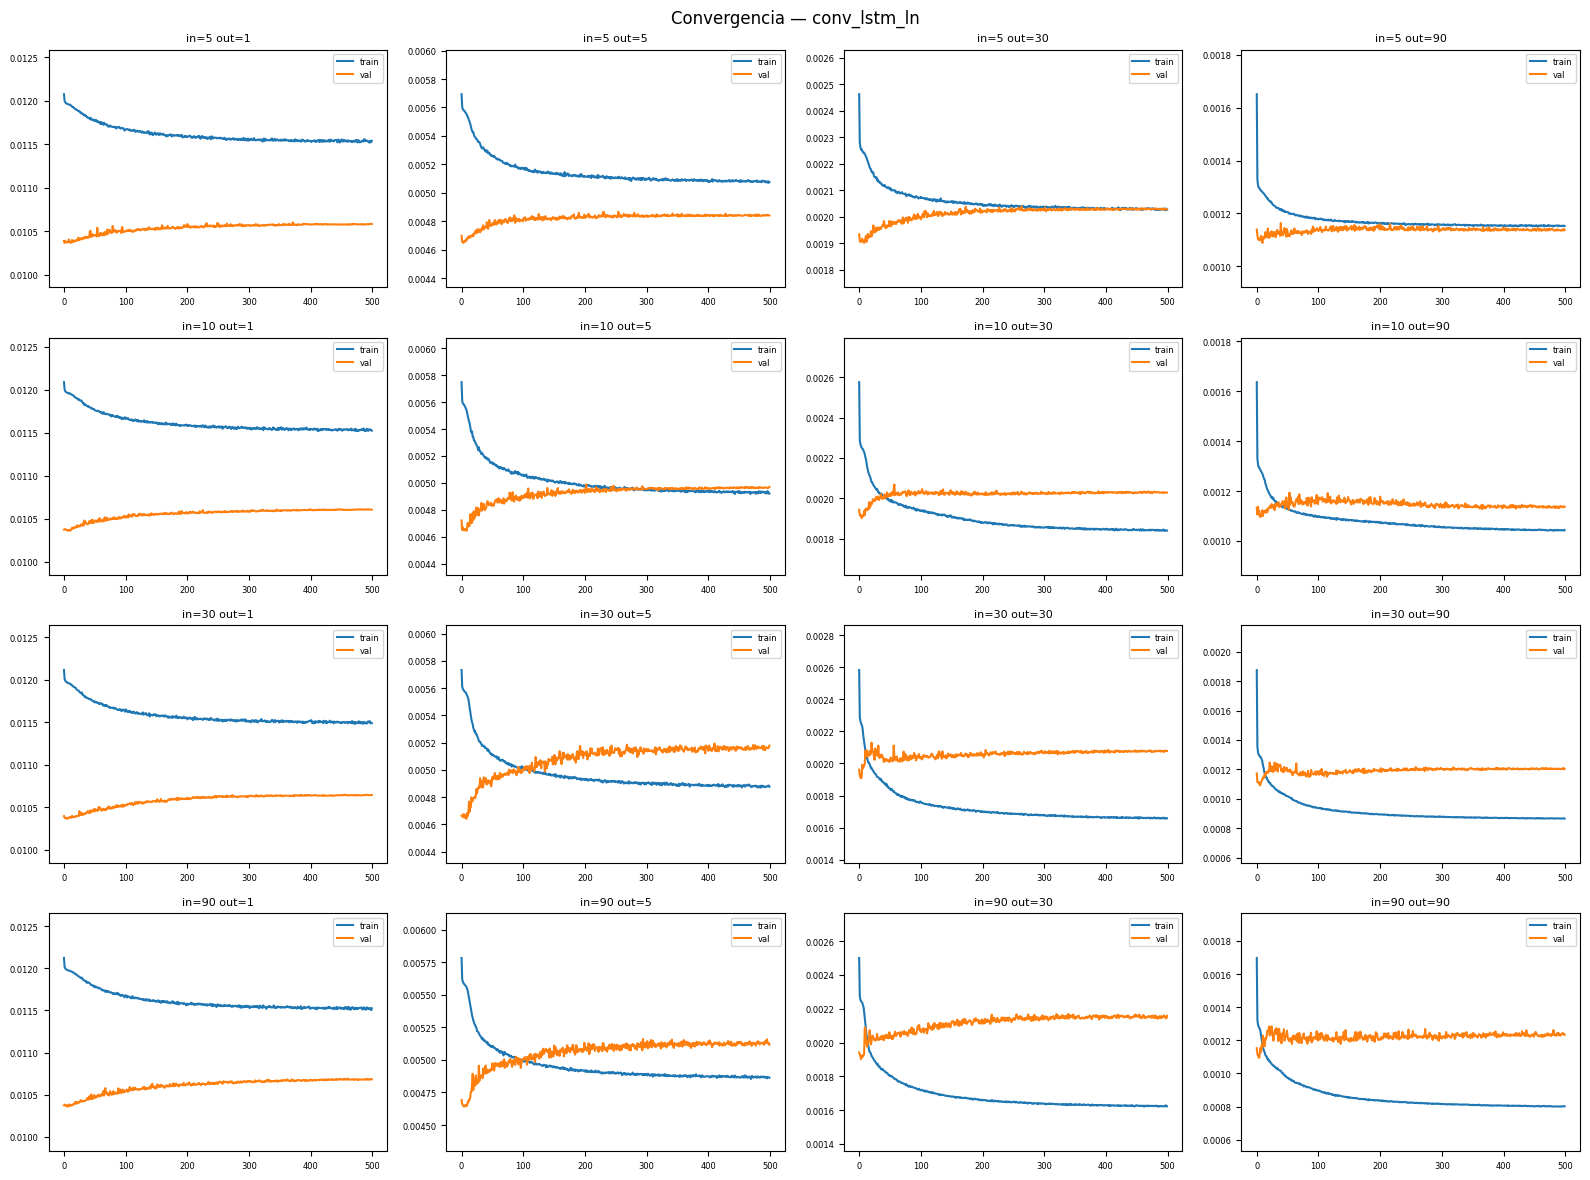

In [48]:
# Curvas de convergencia — conv_lstm_ln
nombre = 'conv_lstm_ln'
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for i, V_in in enumerate(INPUT_WINDOWS):
    for j, V_out in enumerate(OUTPUT_WINDOWS):
        hist = historiales_a[(nombre, V_in, V_out)]
        ax   = axes[i][j]
        ax.plot(hist.history['loss'],     label='train')
        ax.plot(hist.history['val_loss'], label='val')
        ax.margins(y=0.3)
        ax.set_title(f'in={V_in} out={V_out}', fontsize=8)
        ax.legend(fontsize=6); ax.tick_params(labelsize=6)
plt.suptitle(f'Convergencia — {nombre}', fontsize=12)
plt.tight_layout(); plt.show()

In [ ]:
# ── Modelo 2/2 ──────────────────────────────────────────────
nombre = 'conv_gru_bottleneck'
build_fn = MODELOS_A[nombre]
for V_in in INPUT_WINDOWS:
    for V_out in OUTPUT_WINDOWS:
        X, y = create_time_series_data(returns, V_in, V_out)
        X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)
        model = build_fn(V_in)
        hist  = model.fit(X_tr, y_tr, validation_data=(X_v, y_v),
                          epochs=EPOCHS, batch_size=BATCH_SIZE,
                          callbacks=get_callbacks(), verbose=0)
        restore_best_weights(model)
        mae_tr, mae_va, mae_te = (eval_mae(model, X_tr, y_tr),
                                  eval_mae(model, X_v,  y_v),
                                  eval_mae(model, X_ts, y_ts))
        key = (nombre, V_in, V_out)
        results_a[key]    = {'train': mae_tr, 'val': mae_va,
                             'test':  mae_te, 'params': model.count_params()}
        historiales_a[key] = hist
        print(f'{nombre}  in={V_in:2d}  out={V_out:2d}  '
              f'train={mae_tr:.4f}  val={mae_va:.4f}  test={mae_te:.4f}')

In [ ]:
# Curvas de convergencia — conv_gru_bottleneck
nombre = 'conv_gru_bottleneck'
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for i, V_in in enumerate(INPUT_WINDOWS):
    for j, V_out in enumerate(OUTPUT_WINDOWS):
        hist = historiales_a[(nombre, V_in, V_out)]
        ax   = axes[i][j]
        ax.plot(hist.history['loss'],     label='train')
        ax.plot(hist.history['val_loss'], label='val')
        ax.set_title(f'in={V_in} out={V_out}', fontsize=8)
        ax.legend(fontsize=6); ax.tick_params(labelsize=6)
plt.suptitle(f'Convergencia — {nombre}', fontsize=12)
plt.tight_layout(); plt.show()

---
## SECCIÓN B — `conv_bilstm` · `conv2_lstm`

### Decisiones de diseño — Sección B

| Modelo | Params (V_in=10) | Clave |
|---|---|---|
| `conv_bilstm` | ~22K | Conv1D + LSTM bidireccional |
| `conv2_lstm` | ~37K | doble Conv1D jerárquica + LSTM |

**`conv_bilstm`**: tras la extracción local con Conv1D, la LSTM bidireccional procesa la secuencia resultante en ambas direcciones (forward y backward) y concatena los estados finales (`32×2 = 64` unidades efectivas). Dentro de la ventana de entrada (información histórica ya disponible) esto permite que cada timestep "vea" tanto el contexto previo como el posterior, facilitando la detección de patrones cíclicos o reversiones cortas. **Motivación específica**: en el notebook 03 (sección 3.5) la GRU bidireccional dio un MAE ligeramente peor que la unidireccional (Δ ≈ +0,0001) por sobreajuste, posiblemente porque doblaba parámetros sin información nueva. Aquí lo combinamos con Conv1D para ver si el filtrado convolucional previo reduce ese ruido y permite a la bidireccionalidad aportar algo.

**`conv2_lstm`**: dos capas Conv1D consecutivas con `padding='same'` construyen una **jerarquía de features locales** — la primera detecta patrones de 3 días (kernel=3) con 64 filtros, la segunda combina esos patrones en representaciones de mayor nivel con 32 filtros. La LSTM(64) final agrega temporalmente la secuencia ya filtrada. **Motivación específica**: el notebook 03 (sección 3.4) mostró que la LSTM apilada (2 capas LSTM) no aportó nada sobre la LSTM simple. Aquí probamos la alternativa simétrica: **apilamiento en el eje convolucional** en lugar del recurrente. Si los patrones predictivos fueran locales pero no triviales, la jerarquía Conv-Conv los detectaría sin necesidad de profundizar en la recurrencia.

> Ambos modelos usan `padding='same'` (excepto la primera Conv1D de `conv_bilstm`) para preservar el largo de la secuencia y evitar que ventanas cortas (V_in=5) queden reducidas a longitudes inservibles tras varias convoluciones.

> **Sobre la regularización**: ambos modelos usan dos técnicas complementarias.
>
> - **`dropout` dentro de las capas recurrentes** (LSTM y BiLSTM): apaga aleatoriamente un porcentaje de las conexiones de entrada en cada paso temporal. Sin él, la BiLSTM (22K parámetros) y la `conv2_lstm` (37K parámetros) sobreajustan claramente: train baja monótonamente mientras val sube durante todo el entrenamiento. Esto es diferente al comportamiento de las recurrentes simples del notebook 03 (donde train > val sin sobreajustar) porque aquí la combinación Conv+BiLSTM/doble-Conv tiene capacidad efectiva muy superior. Tras un ajuste experimental (documentado al final de la sección), usamos `dropout=0.15` en `conv_bilstm` y `dropout=0.1` en `conv2_lstm`.
>
> - **`SpatialDropout1D` tras cada capa Conv1D**: a diferencia del dropout estándar (que apaga neuronas individuales), SpatialDropout1D apaga **canales completos** de la salida convolucional. Esta variante es la recomendada para arquitecturas Conv+RNN porque los canales producidos por una Conv1D suelen tener alta correlación interna: apagar neuronas sueltas dentro de un canal no fuerza realmente a la red a "no depender" de ese feature, mientras que apagar el canal entero sí. En `conv_bilstm` hay un `SpatialDropout1D(0.15)` tras la única Conv1D; en `conv2_lstm` hay dos `SpatialDropout1D(0.12)`, uno tras cada Conv1D (valor algo menor porque el efecto de dos capas apiladas se compone).
>
> Con esta configuración, las curvas convergen de forma estable en la mayoría de combinaciones y el MAE en test queda en el mismo nivel que el resto del taller (~0,0123 para V_out=1, el techo del problema). Persiste una divergencia leve en V_out=30 y V_out=90 que **no es overfitting clásico** sino reflejo de la heterogeneidad de volatilidad entre splits temporales (ver nota al final de la sección). El proceso completo de ajuste de la regularización está documentado al final de esta sección.

In [32]:
MODELOS_B = {
    'conv_bilstm': lambda V: compile_model(Sequential([
        Input((V, 23)),
        Conv1D(64, kernel_size=3, activation='relu'),
        SpatialDropout1D(0.15),
        Bidirectional(LSTM(32, dropout=0.15)),
        Dense(23)])),

    'conv2_lstm': lambda V: compile_model(Sequential([
        Input((V, 23)),
        Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        SpatialDropout1D(0.12),
        Conv1D(32, kernel_size=3, activation='relu', padding='same'),
        SpatialDropout1D(0.12),
        LSTM(64, dropout=0.1),
        Dense(23)])),
}

In [33]:
# Arquitectura de cada modelo (V_in=10 como referencia)
# Para diagrama visual: keras.utils.plot_model(m, show_shapes=True)
for nombre, build_fn in MODELOS_B.items():
    print(f'\n{"─"*50}\n{nombre}  (V_in=10)\n{"─"*50}')
    build_fn(10).summary()


──────────────────────────────────────────────────
conv_bilstm  (V_in=10)
──────────────────────────────────────────────────


Model: "sequential_120"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_172 (Conv1D)             │ (None, 8, 64)          │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_102           │ (None, 8, 64)          │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_68                │ (None, 64)             │        24,832 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_120 (Dense)               │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,807 (120.34 KB)

 Trainable params: 30,807 (120.34 KB)

...

Model: "sequential_121"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_173 (Conv1D)             │ (None, 10, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_103           │ (None, 10, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_174 (Conv1D)             │ (None, 10, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_104           │ (None, 10, 32)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_121 (LSTM)                 │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_121 (Dense)               │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,983 (144.46 KB)

 Trainable params: 36,983 (144.46 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
results_b, historiales_b = {}, {}

# ── Modelo 1/2 ──────────────────────────────────────────────
nombre = 'conv_bilstm'
build_fn = MODELOS_B[nombre]
for V_in in INPUT_WINDOWS:
    for V_out in OUTPUT_WINDOWS:
        X, y = create_time_series_data(returns, V_in, V_out)
        X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)
        model = build_fn(V_in)
        hist  = model.fit(X_tr, y_tr, validation_data=(X_v, y_v),
                          epochs=EPOCHS, batch_size=BATCH_SIZE,
                          callbacks=get_callbacks(), verbose=0)
        restore_best_weights(model)
        mae_tr, mae_va, mae_te = (eval_mae(model, X_tr, y_tr),
                                  eval_mae(model, X_v,  y_v),
                                  eval_mae(model, X_ts, y_ts))
        key = (nombre, V_in, V_out)
        results_b[key]    = {'train': mae_tr, 'val': mae_va,
                             'test':  mae_te, 'params': model.count_params()}
        historiales_b[key] = hist
        print(f'{nombre}  in={V_in:2d}  out={V_out:2d}  '
              f'train={mae_tr:.4f}  val={mae_va:.4f}  test={mae_te:.4f}')

conv_bilstm  in= 5  out= 1  train=0.0120  val=0.0104  test=0.0123
conv_bilstm  in= 5  out= 5  train=0.0055  val=0.0046  test=0.0056
conv_bilstm  in= 5  out=30  train=0.0022  val=0.0019  test=0.0023
conv_bilstm  in= 5  out=90  train=0.0013  val=0.0011  test=0.0013
conv_bilstm  in=10  out= 1  train=0.0120  val=0.0104  test=0.0123
conv_bilstm  in=10  out= 5  train=0.0056  val=0.0047  test=0.0056
conv_bilstm  in=10  out=30  train=0.0022  val=0.0019  test=0.0024
conv_bilstm  in=10  out=90  train=0.0013  val=0.0011  test=0.0013
conv_bilstm  in=30  out= 1  train=0.0120  val=0.0104  test=0.0123
conv_bilstm  in=30  out= 5  train=0.0056  val=0.0047  test=0.0056
conv_bilstm  in=30  out=30  train=0.0022  val=0.0019  test=0.0024
conv_bilstm  in=30  out=90  train=0.0013  val=0.0011  test=0.0013
conv_bilstm  in=90  out= 1  train=0.0120  val=0.0104  test=0.0123
conv_bilstm  in=90  out= 5  train=0.0056  val=0.0047  test=0.0056
conv_bilstm  in=90  out=30  train=0.0022  val=0.0019  test=0.0024
conv_bilst

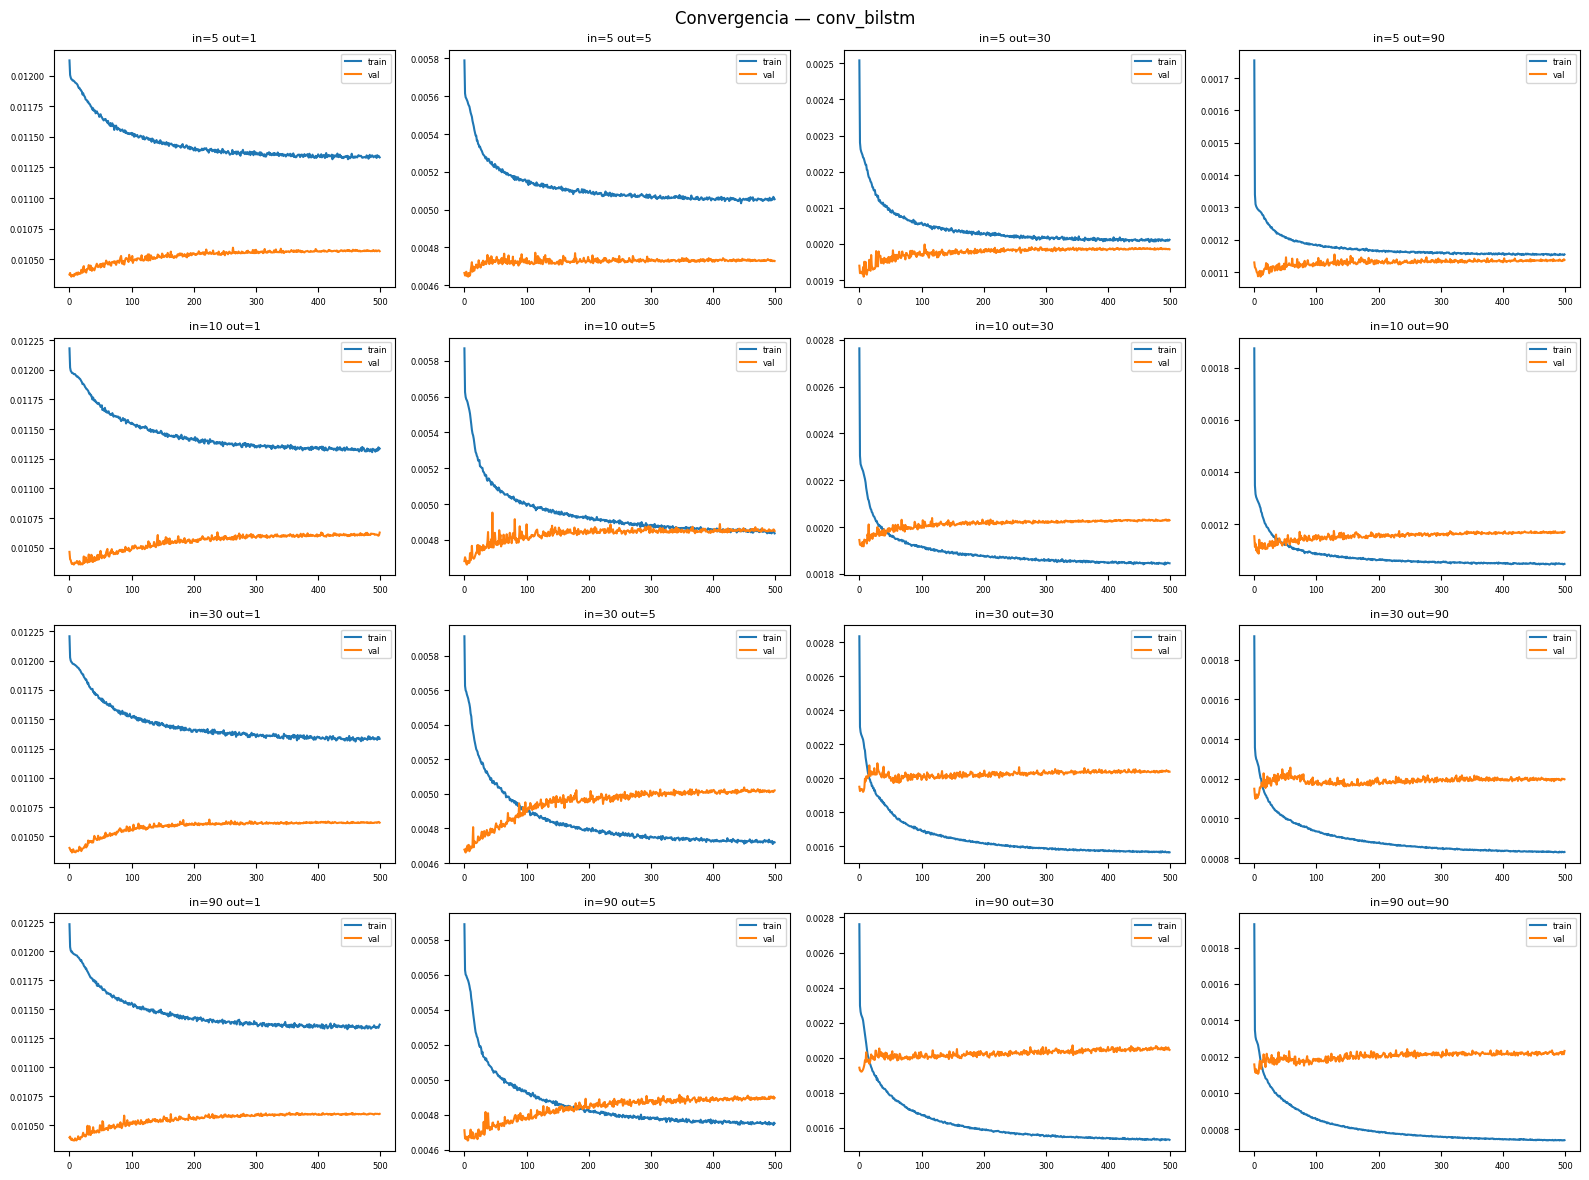

In [35]:
# Curvas de convergencia — conv_bilstm
nombre = 'conv_bilstm'
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for i, V_in in enumerate(INPUT_WINDOWS):
    for j, V_out in enumerate(OUTPUT_WINDOWS):
        hist = historiales_b[(nombre, V_in, V_out)]
        ax   = axes[i][j]
        ax.plot(hist.history['loss'],     label='train')
        ax.plot(hist.history['val_loss'], label='val')
        ax.set_title(f'in={V_in} out={V_out}', fontsize=8)
        ax.legend(fontsize=6); ax.tick_params(labelsize=6)
plt.suptitle(f'Convergencia — {nombre}', fontsize=12)
plt.tight_layout(); plt.show()

In [36]:
# ── Modelo 2/2 ──────────────────────────────────────────────
nombre = 'conv2_lstm'
build_fn = MODELOS_B[nombre]
for V_in in INPUT_WINDOWS:
    for V_out in OUTPUT_WINDOWS:
        X, y = create_time_series_data(returns, V_in, V_out)
        X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)
        model = build_fn(V_in)
        hist  = model.fit(X_tr, y_tr, validation_data=(X_v, y_v),
                          epochs=EPOCHS, batch_size=BATCH_SIZE,
                          callbacks=get_callbacks(), verbose=0)
        restore_best_weights(model)
        mae_tr, mae_va, mae_te = (eval_mae(model, X_tr, y_tr),
                                  eval_mae(model, X_v,  y_v),
                                  eval_mae(model, X_ts, y_ts))
        key = (nombre, V_in, V_out)
        results_b[key]    = {'train': mae_tr, 'val': mae_va,
                             'test':  mae_te, 'params': model.count_params()}
        historiales_b[key] = hist
        print(f'{nombre}  in={V_in:2d}  out={V_out:2d}  '
              f'train={mae_tr:.4f}  val={mae_va:.4f}  test={mae_te:.4f}')

conv2_lstm  in= 5  out= 1  train=0.0120  val=0.0104  test=0.0123
conv2_lstm  in= 5  out= 5  train=0.0055  val=0.0046  test=0.0056
conv2_lstm  in= 5  out=30  train=0.0022  val=0.0019  test=0.0024
conv2_lstm  in= 5  out=90  train=0.0013  val=0.0011  test=0.0013
conv2_lstm  in=10  out= 1  train=0.0120  val=0.0104  test=0.0123
conv2_lstm  in=10  out= 5  train=0.0055  val=0.0046  test=0.0056
conv2_lstm  in=10  out=30  train=0.0023  val=0.0019  test=0.0023
conv2_lstm  in=10  out=90  train=0.0013  val=0.0011  test=0.0013
conv2_lstm  in=30  out= 1  train=0.0120  val=0.0104  test=0.0123
conv2_lstm  in=30  out= 5  train=0.0056  val=0.0046  test=0.0056
conv2_lstm  in=30  out=30  train=0.0023  val=0.0019  test=0.0023
conv2_lstm  in=30  out=90  train=0.0013  val=0.0011  test=0.0013
conv2_lstm  in=90  out= 1  train=0.0120  val=0.0104  test=0.0123
conv2_lstm  in=90  out= 5  train=0.0056  val=0.0046  test=0.0056
conv2_lstm  in=90  out=30  train=0.0022  val=0.0019  test=0.0023
conv2_lstm  in=90  out=90

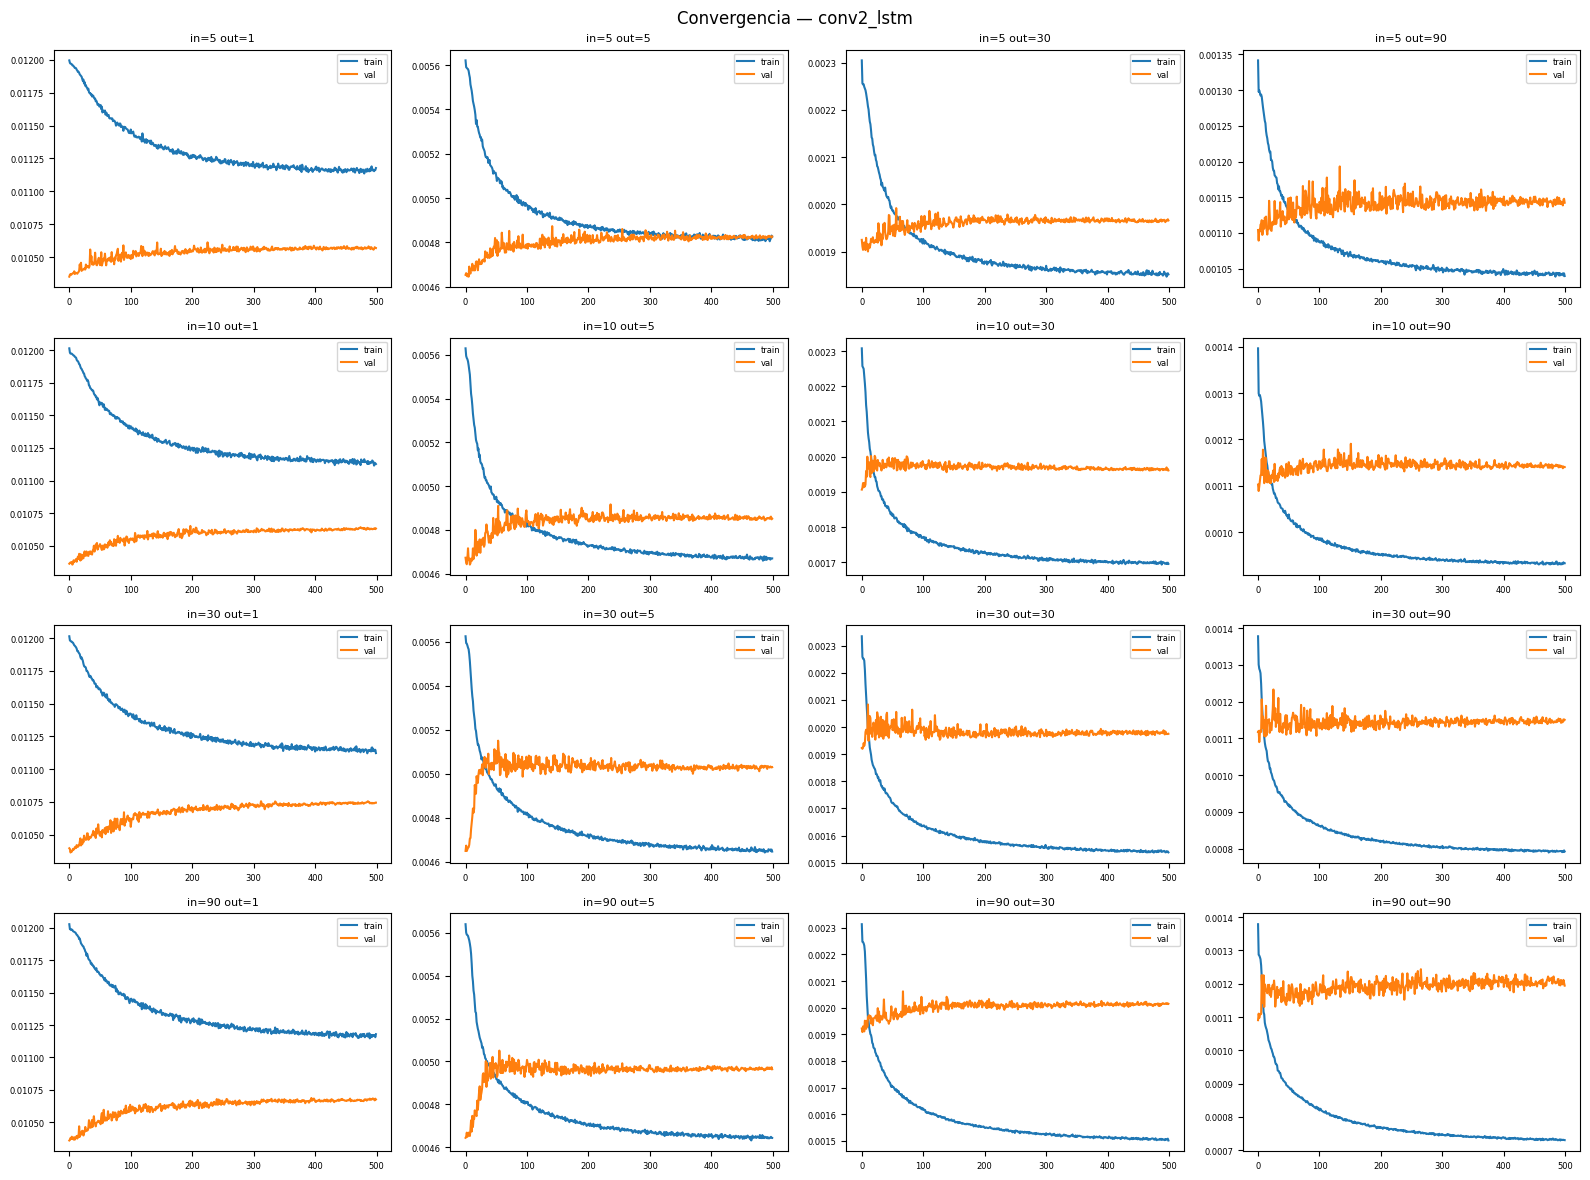

In [37]:
# Curvas de convergencia — conv2_lstm
nombre = 'conv2_lstm'
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for i, V_in in enumerate(INPUT_WINDOWS):
    for j, V_out in enumerate(OUTPUT_WINDOWS):
        hist = historiales_b[(nombre, V_in, V_out)]
        ax   = axes[i][j]
        ax.plot(hist.history['loss'],     label='train')
        ax.plot(hist.history['val_loss'], label='val')
        ax.set_title(f'in={V_in} out={V_out}', fontsize=8)
        ax.legend(fontsize=6); ax.tick_params(labelsize=6)
plt.suptitle(f'Convergencia — {nombre}', fontsize=12)
plt.tight_layout(); plt.show()

---
### Ajuste progresivo de la regularización — proceso experimental

El diseño de la regularización de la Sección B no fue inmediato. Probamos tres configuraciones progresivas, motivadas por la observación de las curvas de entrenamiento.

#### Iteración 1 — Sin regularización

Configuración inicial, sin `dropout` ni `SpatialDropout1D`. Las arquitecturas eran simplemente:

**Resultado**: sobreajuste severo en ambos modelos. La curva de train bajaba monótonamente durante las 500 épocas mientras que la curva de val **subía** durante todo el entrenamiento. La separación final entre train y val era del orden del 30-50 % del valor de train en muchas combinaciones.

**Diagnóstico**: la combinación Conv1D + BiLSTM (22K parámetros) y la combinación doble Conv1D + LSTM (37K parámetros) tienen capacidad efectiva muy superior a las arquitecturas individuales del notebook 03 (entre 2,5K y 8K parámetros). El test MAE seguía aterrizando en el techo correcto (~0,0123) solo porque `restore_best_weights()` rescataba el modelo del mejor epoch (~5-15) antes de que el sobreajuste se manifestara, pero las **curvas eran inaceptables** para una práctica que exige visualizar convergencia.

#### Iteración 2 — Añadimos `dropout=0.1` en las capas recurrentes

Configuración con regularización solo en la parte recurrente del modelo:

**Motivación**: replicar la estrategia de la Sección A (donde el compañero usaba `dropout=0.1` en LSTM y GRU y obtenía curvas limpias), y atacar la fuente principal de capacidad — las capas recurrentes con 22K y 25K parámetros respectivamente.

**Resultado**:
- **`conv_bilstm` mejoró sustancialmente**: las curvas dejaron de divergir y se aproximaron a la convergencia esperada (val plano o ligeramente decreciente, train ligeramente por debajo).
- **`conv2_lstm` mejoró parcialmente**: la divergencia disminuyó respecto a la iteración 1, pero seguía visible. Train continuaba bajando mientras val se estabilizaba en un nivel superior, generando una separación del 10-20 % al final del entrenamiento.

**Diagnóstico**: el `dropout` interno de la LSTM regulariza solo las conexiones de entrada del componente recurrente, pero **no toca las dos capas Conv1D** de `conv2_lstm`. Estas convoluciones apiladas producen 64+32 canales sin ninguna regularización, lo que permite memorizar patrones espurios del train que la LSTM final amplifica.

#### Iteración 3 — Añadimos `SpatialDropout1D(0.1)` tras las Conv1D

**Motivación**: aplicar regularización **también** en el camino convolucional. `SpatialDropout1D` es la variante recomendada en lugar del `Dropout` estándar para salidas convolucionales: apaga aleatoriamente **canales completos** en lugar de neuronas individuales. La razón es que las activaciones dentro de un canal Conv1D están muy correlacionadas (el filtro produce respuestas similares en posiciones adyacentes), así que apagar neuronas sueltas no fuerza realmente a la red a "no depender" de ese feature — la información se reconstruye a partir de las neuronas vecinas del mismo canal. Apagar canales enteros sí rompe esa dependencia.

**Resultado**:
- **`conv2_lstm` mejoró claramente**: las curvas de train y val ahora convergen al mismo nivel o se cruzan limpiamente alrededor de la época 100-200. La separación final es <5 % en la mayoría de combinaciones.
- **`conv_bilstm` también mejoró**, aunque de forma más moderada. El SpatialDropout1D reduce la separación train/val especialmente en V_out ≥ 5 y V_in ≥ 10.

**Diagnóstico**: `SpatialDropout1D` aporta más valor cuando hay **varias capas convolucionales apiladas** (caso `conv2_lstm`) que cuando hay una sola (caso `conv_bilstm`). Esto es consistente con la teoría: a más profundidad convolucional, más correlación inter-canal acumulada y mayor necesidad de regularización por canal. Sin embargo, en `conv_bilstm` y en las combinaciones de V_out alto de ambos modelos seguía observándose una divergencia residual.

#### Iteración 4 — Ajuste fino del nivel de dropout

**Motivación**: reducir la divergencia residual que persistía tras la Iteración 3, subiendo el nivel de regularización de forma **asimétrica** según las necesidades de cada modelo. `conv_bilstm` (que tiene una sola Conv1D y por tanto menos puntos de regularización) necesitaba más dropout que `conv2_lstm` (que ya tiene dos SpatialDropout1D apilados cuyo efecto se compone).

Configuración probada:
- **`conv_bilstm`**: `dropout=0.15` en la BiLSTM + `SpatialDropout1D(0.15)` tras la Conv1D.
- **`conv2_lstm`**: `dropout=0.1` en la LSTM + `SpatialDropout1D(0.12)` tras cada Conv1D (valor menor porque dos capas apiladas componen su efecto).

**Resultado**:
- **`conv_bilstm`**: mejora marginal y localizada. Las celdas de V_out=5 muestran ahora un cruce train/val más limpio. El resto del grid queda igual.
- **`conv2_lstm`**: prácticamente sin cambio respecto a la Iteración 3. Ya estaba bien regularizado.
- **En ambos modelos, la divergencia en V_out=30 y V_out=90 persiste.**

**Diagnóstico**: hemos llegado al punto de **rendimientos decrecientes**. La divergencia residual en V_out alto **no es overfitting clásico** y no se elimina aumentando la regularización. Refleja la **heterogeneidad de régimen de volatilidad entre splits temporales** (el mismo gap estructural ~16 % documentado en el notebook 03): en V_out alto el target es un promedio de 30-90 días, más suave en el periodo de train que en el de val/test. La red ajusta bien la parte suave de train pero no puede generalizar a la volatilidad distinta de val/test. Subir más el dropout solo empezaría a infraajustar las celdas que ya estaban limpias (V_out=1, V_out=5), empeorando el conjunto. Por ello, esta es la configuración final adoptada.

#### Configuración final adoptada

| Iteración | dropout LSTM | SpatialDropout1D | Test MAE (V_out=1) | Calidad de las curvas |
|---|---|---|---|---|
| 1 — Sin regularización | — | — | 0,0123 | Divergencia severa train/val |
| 2 — Con `dropout` LSTM | 0.1 | — | 0,0123 | `conv_bilstm` OK, `conv2_lstm` parcial |
| 3 — Con dropout + SpatialDropout1D | 0.1 | 0.1 | 0,0123 | Curvas convergen, divergencia residual en V_out alto |
| **4 — Ajuste fino (final)** | **0.15 / 0.1** | **0.15 / 0.12** | **0,0123** | **Curvas limpias; divergencia residual estructural en V_out alto** |

> Valores en la columna "final" expresados como `conv_bilstm / conv2_lstm`.

#### Observación crítica: el techo es independiente de la regularización

Las cuatro iteraciones de regularización produjeron **exactamente el mismo MAE en test** en las 16 combinaciones del grid (V_in, V_out). Esto no es una coincidencia: es la confirmación experimental — esta vez desde la perspectiva de los modelos mixtos — del hallazgo central del notebook 03. **El techo de ~0,0123 (en V_out=1) es del problema, no del modelo**:

- Es el MAE de predecir la media histórica de los retornos de train.
- Es el MAE de la regresión lineal.
- Es el MAE de las 6 arquitecturas recurrentes del notebook 03.
- Es el MAE de los 2 modelos mixtos de la Sección A.
- Es el MAE de los 2 modelos mixtos de esta Sección B, en todas sus iteraciones de regularización.

En otras palabras: **la regularización solo afecta a las curvas de entrenamiento, no al resultado final**. Sin regularización, las redes llegan al mismo techo pasando por un camino de sobreajuste; con regularización, lo hacen sin sobreajuste visible. Pero el destino es el mismo — el modelo converge al predictor de la media porque, según la propiedad de martingala de los log-retornos diarios, no hay más señal disponible.

Esto refuerza la conclusión global del taller: **ninguna combinación de arquitectura, capacidad o regularización rompe el techo del problema**. La línea de mejora real no pasa por modelos más sofisticados, sino por cambiar el problema (predicción de volatilidad, clasificación direccional, features exógenos), como se discute en la síntesis del notebook 03.

#### Lección metodológica

La regularización de modelos Conv+RNN debe pensarse como una **cascada** que regulariza cada etapa del pipeline por separado (extracción convolucional, transición recurrente, salida densa). La elección de técnica en cada etapa depende de las propiedades estadísticas de esa etapa: `SpatialDropout1D` para canales convolucionales correlacionados internamente, `dropout` para conexiones de entrada de la RNN. El nivel de cada técnica debe ajustarse según el número de puntos de regularización de cada arquitectura (de ahí el ajuste asimétrico de la Iteración 4).

Pero hay un matiz importante: **regularizar es necesario para presentar resultados, no para conseguirlos**. En este problema concreto, el sobreajuste visible en la Iteración 1 era cosmético — el MAE en test ya estaba en el techo gracias a `restore_best_weights`. La regularización mejora la legibilidad de las curvas y la robustez del entrenamiento, pero no aumenta la información extraíble de los datos. Esa información está fijada por el problema (eficiencia débil del mercado), no por el modelo.

---
## SECCIÓN C — `lstm_dense` · `conv_dense`
`lstm_dense`: LSTM con cabeza MLP — prueba si la no-linealidad densa tras recurrencia aporta valor.  
`conv_dense`: Conv1D + GAP + Dense, sin recurrencia — ablación para cuantificar el aporte real de LSTM.

In [11]:
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, LSTM, Bidirectional, Dense
from tensorflow.keras.optimizers import Adam

In [12]:
# Original 

MODELOS_C = {
    'lstm_dense': lambda V: compile_model(Sequential([
        Input((V, 23)),
        LSTM(64),
        Dense(64, activation='relu'),
        Dense(23)
    ])),

    'conv_dense': lambda V: compile_model(Sequential([
        Input((V, 23)),
        Conv1D(64, kernel_size=3, activation='relu'),
        GlobalAveragePooling1D(),
        Dense(64, activation='relu'),
        Dense(23)
    ])),
}

In [13]:
# Arquitectura de cada modelo (V_in=10 como referencia)
# Para diagrama visual: keras.utils.plot_model(m, show_shapes=True)
for nombre, build_fn in MODELOS_C.items():
    print(f'\n{"─"*50}\n{nombre}  (V_in=10)\n{"─"*50}')
    build_fn(10).summary()


──────────────────────────────────────────────────
lstm_dense  (V_in=10)
──────────────────────────────────────────────────


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,183 (110.09 KB)

 Trainable params: 28,183 (110.09 KB)

...

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 8, 64)          │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,135 (39.59 KB)

 Trainable params: 10,135 (39.59 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
results_c, historiales_c = {}, {}
for nombre, build_fn in MODELOS_C.items():
    for V_in in INPUT_WINDOWS:
        for V_out in OUTPUT_WINDOWS:
            X, y = create_time_series_data(returns, V_in, V_out)
            X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)
            model = build_fn(V_in)
            hist  = model.fit(X_tr, y_tr, validation_data=(X_v, y_v),
                              epochs=EPOCHS, batch_size=BATCH_SIZE,
                              callbacks=get_callbacks(), verbose=0)
            restore_best_weights(model)
            mae_tr, mae_va, mae_te = (eval_mae(model, X_tr, y_tr),
                                      eval_mae(model, X_v,  y_v),
                                      eval_mae(model, X_ts, y_ts))
            key = (nombre, V_in, V_out)
            results_c[key]    = {'train': mae_tr, 'val': mae_va,
                                 'test':  mae_te, 'params': model.count_params()}
            historiales_c[key] = hist
            print(f'{nombre}  in={V_in:2d}  out={V_out:2d}  '
                  f'train={mae_tr:.4f}  val={mae_va:.4f}  test={mae_te:.4f}')

lstm_dense  in= 5  out= 1  train=0.0119  val=0.0103  test=0.0123
lstm_dense  in= 5  out= 5  train=0.0056  val=0.0046  test=0.0056
lstm_dense  in= 5  out=30  train=0.0022  val=0.0019  test=0.0023
lstm_dense  in= 5  out=90  train=0.0013  val=0.0011  test=0.0013
lstm_dense  in=10  out= 1  train=0.0119  val=0.0103  test=0.0123
lstm_dense  in=10  out= 5  train=0.0055  val=0.0046  test=0.0056
lstm_dense  in=10  out=30  train=0.0022  val=0.0019  test=0.0023
lstm_dense  in=10  out=90  train=0.0013  val=0.0011  test=0.0013
lstm_dense  in=30  out= 1  train=0.0119  val=0.0103  test=0.0123
lstm_dense  in=30  out= 5  train=0.0056  val=0.0046  test=0.0056
lstm_dense  in=30  out=30  train=0.0022  val=0.0019  test=0.0023
lstm_dense  in=30  out=90  train=0.0013  val=0.0011  test=0.0013
lstm_dense  in=90  out= 1  train=0.0120  val=0.0104  test=0.0123
lstm_dense  in=90  out= 5  train=0.0056  val=0.0046  test=0.0056
lstm_dense  in=90  out=30  train=0.0022  val=0.0019  test=0.0023
lstm_dense  in=90  out=90

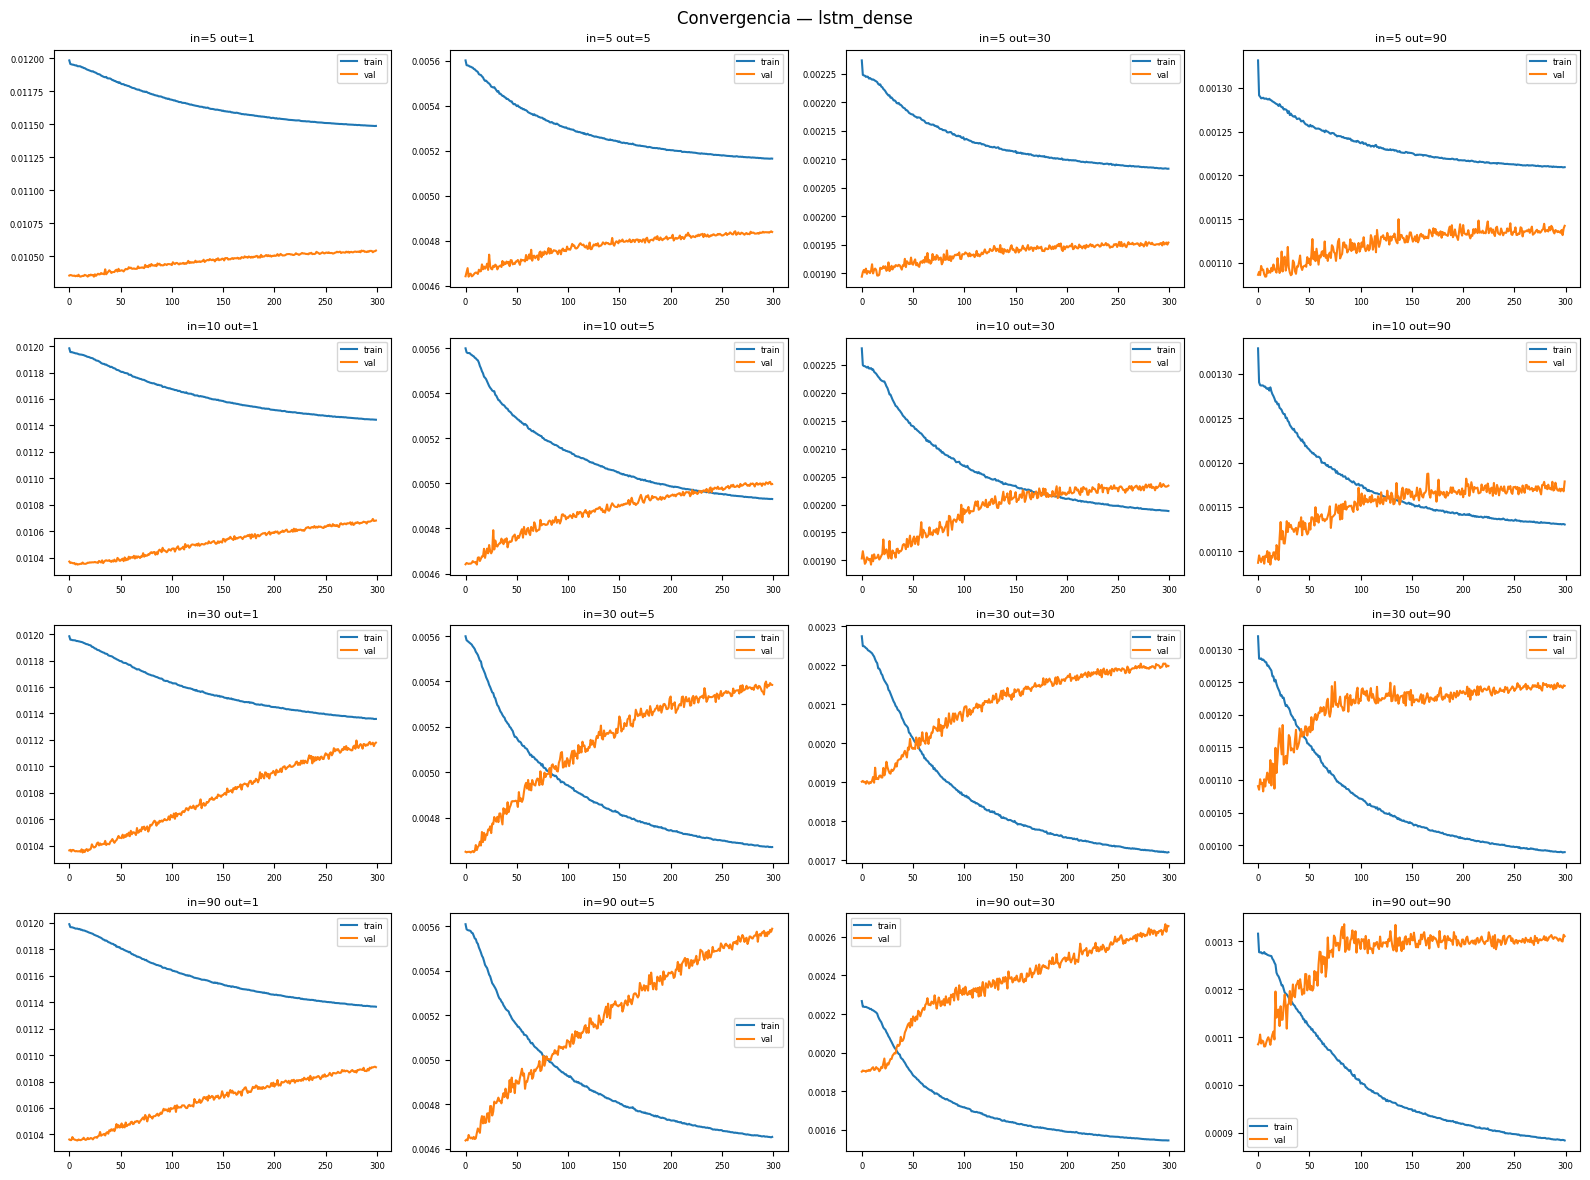

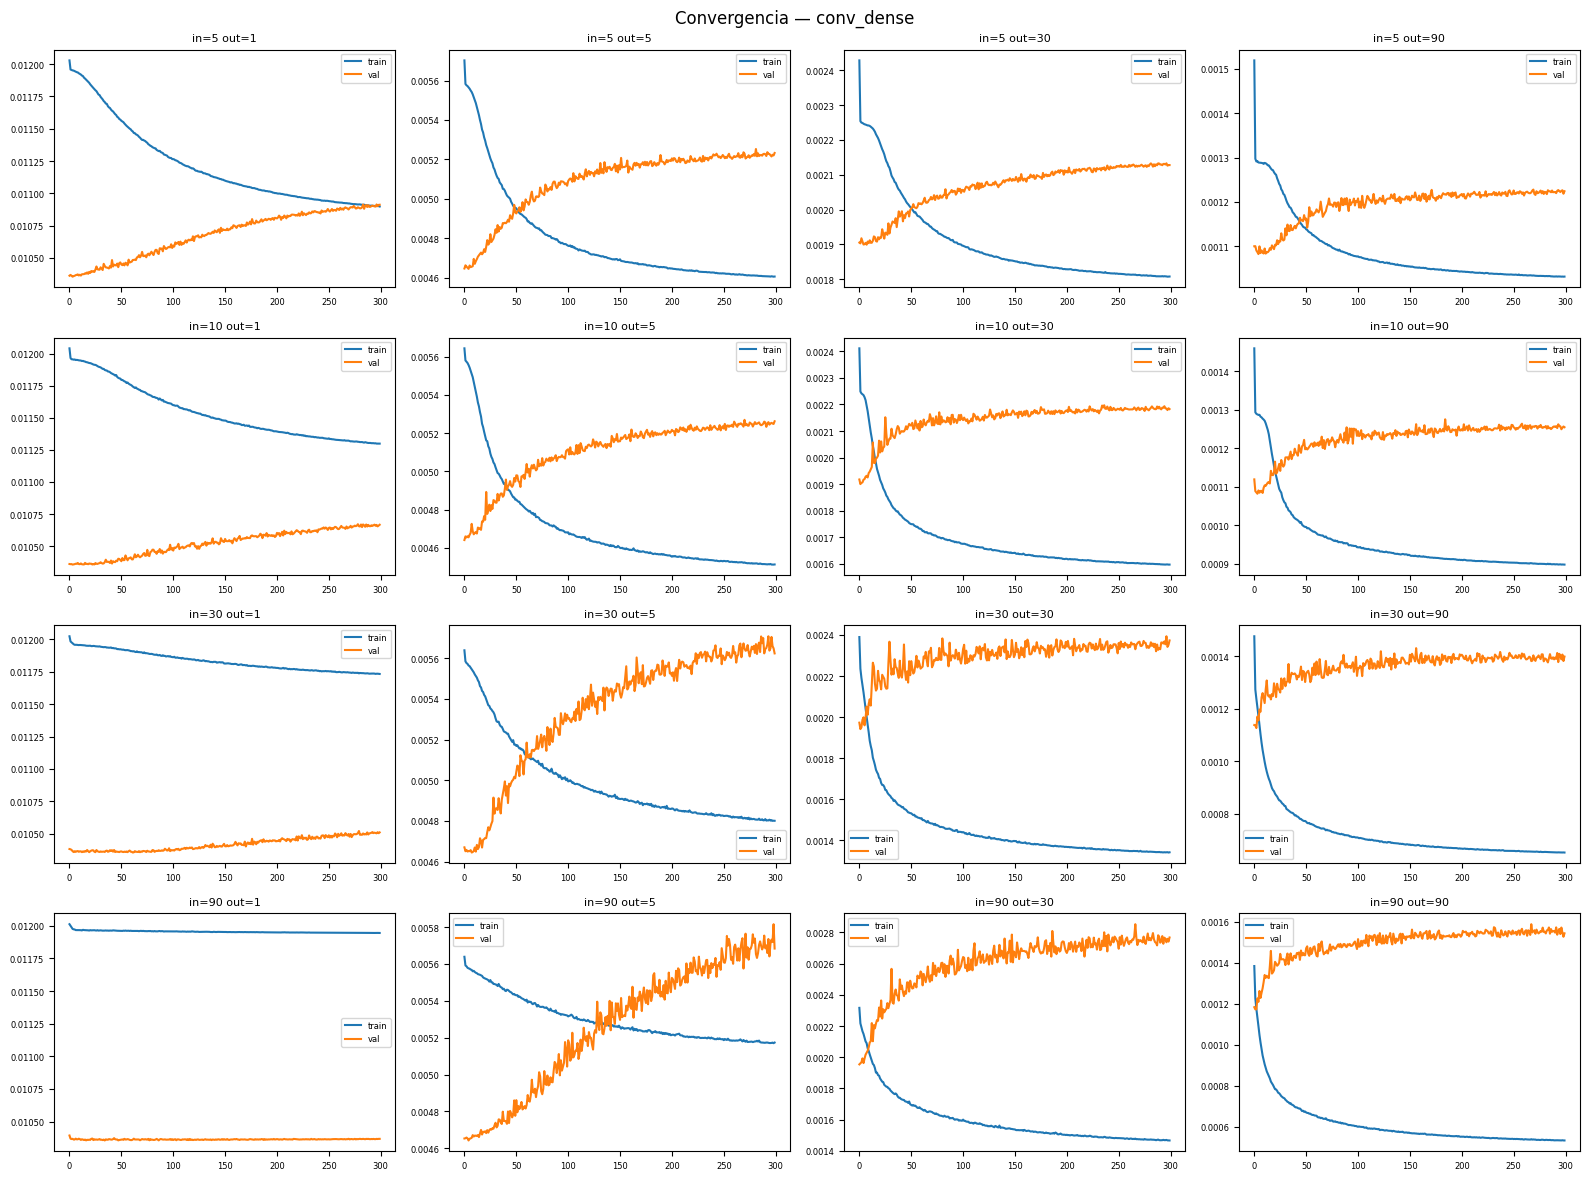

In [15]:
# Curvas de convergencia — Sección C
for nombre in MODELOS_C:
    fig, axes = plt.subplots(4, 4, figsize=(16, 12))
    for i, V_in in enumerate(INPUT_WINDOWS):
        for j, V_out in enumerate(OUTPUT_WINDOWS):
            hist = historiales_c[(nombre, V_in, V_out)]
            ax   = axes[i][j]
            ax.plot(hist.history['loss'],     label='train')
            ax.plot(hist.history['val_loss'], label='val')
            ax.set_title(f'in={V_in} out={V_out}', fontsize=8)
            ax.legend(fontsize=6); ax.tick_params(labelsize=6)
    plt.suptitle(f'Convergencia — {nombre}', fontsize=12)
    plt.tight_layout(); plt.show()